# Evaluating embeddings: link prediction & node classification

`hypegrl.evaluation` provides dataset-agnostic tools to benchmark *any* embedder
under a common protocol:

- **Link prediction** — hide a fraction of the edges, embed the remaining graph,
  and rank the held-out edges against true non-links by embedding distance.
- **Node classification** — a distance-based k-nearest-neighbour classifier in
  the embedding, probing how well the geometry organises node labels.

The underlying metrics (precision/recall/F1, the KNN classifier) are delegated
to scikit-learn; only the ranking protocol and the geodesic distances are
hyperbolic-specific.

In [1]:
# Uncomment to install hypeGRL:
# !pip install git+https://github.com/cicadaUY/hypeGRL

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

from hypegrl.embedders.poincare_maps import PoincareMapsEmbedder
from hypegrl.embedders.poincare_embeddings import PoincareEmbeddingsEmbedder
from hypegrl.evaluation import (
    link_prediction_split, training_graph,
    pairwise_distance_matrix, candidate_scores,
    precision_recall_f1_at_k, lift_curve,
    hyperbolic_knn_classification,
)

## Link prediction — hiding edges

`link_prediction_split` retains each edge with probability `q` and removes the
rest, partitioning all node pairs into three disjoint sets: the retained edges
`omega_E` (the observed graph), the removed edges `omega_R` (held-out
positives), and the true non-links `omega_N`. We use the Les Misérables
co-appearance network.

In [2]:
G = nx.les_miserables_graph()
split = link_prediction_split(G, q=0.9, seed=0)
print(f"retained  (omega_E): {len(split.omega_E)}")
print(f"removed   (omega_R): {len(split.omega_R)}   <- held-out positives")
print(f"non-links (omega_N): {len(split.omega_N)}")

retained  (omega_E): 217
removed   (omega_R): 37   <- held-out positives
non-links (omega_N): 2672


## Embed the observed graph, rank the candidates

`training_graph` builds the observed graph `(V, omega_E)` (all nodes, only
retained edges). We embed it, take the pairwise geodesic distances with
`pairwise_distance_matrix`, and read one score per candidate pair with
`candidate_scores`. Ranking is by **distance** (`higher_is_link=False`): closer
pairs are more likely to be links.

In [3]:
G_train = training_graph(G, split)
emb = PoincareMapsEmbedder(d=2, n_steps=500, log_every=999, random_state=0).fit(G_train)

# Score on the exact representation, not embeddings() ball coordinates: the ball
# chart saturates past r ≈ 12, so distances read off it are wrong at large radius.
D = pairwise_distance_matrix(emb.embeddings_representation())   # (N, N) geodesic distances
scores, is_positive = candidate_scores(split, D, nodes=emb.nodes())

m = precision_recall_f1_at_k(scores, is_positive, higher_is_link=False)
print(f"Predicting the top |omega_R| = {m['n_positives']} candidates as links:")
print(f"  true positives: {m['tp']}/{m['n_positives']}")
print(f"  F1 = {100 * m['f1']:.1f}%   (precision = recall = F1 at this cutoff)")

Step    0 | Loss: 229.526421


Step  499 | Loss: 42.613209
Predicting the top |omega_R| = 37 candidates as links:
  true positives: 18/37
  F1 = 48.6%   (precision = recall = F1 at this cutoff)


## Decile lift — are the true edges near the top?

`lift_curve` splits the ranked candidates into deciles and counts how many
held-out edges land in each. `captured_in_first_bin` is the share recovered in
the top 10%; per-decile `lift` is the bin's positive rate over the random
baseline (1.0 = no better than chance).

first decile captures 23/37 held-out edges (62% in the top 10%)


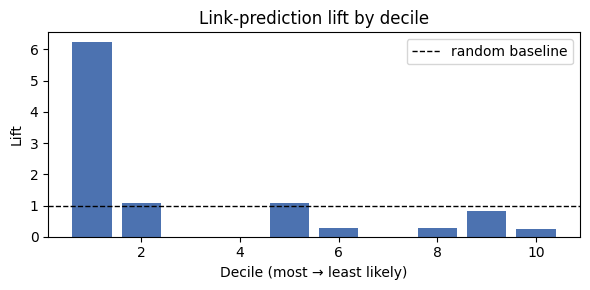

In [4]:
curve = lift_curve(scores, is_positive, n_bins=10, higher_is_link=False)
captured, total = curve.captured_in_first_bin
print(f"first decile captures {captured}/{total} held-out edges "
      f"({100 * captured / total:.0f}% in the top 10%)")

plt.figure(figsize=(6, 3))
plt.bar(range(1, 11), curve.lift, color="#4c72b0")
plt.axhline(1.0, ls="--", c="k", lw=1, label="random baseline")
plt.xlabel("Decile (most → least likely)"); plt.ylabel("Lift")
plt.title("Link-prediction lift by decile"); plt.legend()
plt.tight_layout(); plt.show()

## Average over splits and compare methods

The split is random, so we average over seeds. Swapping the embedder is a
one-line change — here we compare Poincaré Maps with Poincaré Embeddings.

In [5]:
def link_prediction_f1(make_embedder, seeds=range(5)):
    f1s = []
    for s in seeds:
        sp = link_prediction_split(G, q=0.9, seed=s)
        e = make_embedder(s).fit(training_graph(G, sp))
        Dm = pairwise_distance_matrix(e.embeddings_representation())
        sc, pos = candidate_scores(sp, Dm, nodes=e.nodes())
        f1s.append(100 * precision_recall_f1_at_k(sc, pos, higher_is_link=False)["f1"])
    return np.mean(f1s), np.std(f1s)

methods = {
    "Poincare Maps":       lambda s: PoincareMapsEmbedder(d=2, n_steps=500, log_every=999, random_state=s),
    "Poincare Embeddings": lambda s: PoincareEmbeddingsEmbedder(d=2, n_steps=500, log_every=999, random_state=s),
}
for name, make in methods.items():
    mean, std = link_prediction_f1(make)
    print(f"{name:16s} F1 = {mean:4.1f} ± {std:.1f}")

Step    0 | Loss: 229.526421


Step  499 | Loss: 42.613209
Step    0 | Loss: 133.401930


Step  499 | Loss: 35.808722
Step    0 | Loss: 171.672821


Step  499 | Loss: 38.955938
Step    0 | Loss: 122.832839


Step  499 | Loss: 32.041575
Step    0 | Loss: 220.774416


...

Step  499 | Loss: 2501.922636
Step    0 | Loss: 5882.060723
Step   19 | Loss: 5879.837260
Step    0 | Loss: 5879.760737


Step  499 | Loss: 2226.240786
Step    0 | Loss: 5842.669927
Step   19 | Loss: 5840.329060
Step    0 | Loss: 5840.494201


Step  499 | Loss: 2413.156907
Step    0 | Loss: 5709.015570
Step   19 | Loss: 5707.067091
Step    0 | Loss: 5706.984127


Step  499 | Loss: 2158.209315
Step    0 | Loss: 5488.845993
Step   19 | Loss: 5486.616225
Step    0 | Loss: 5486.672597


Step  499 | Loss: 2388.012136
Poincare Embeddings F1 = 35.9 ± 7.6


## Node classification — distance-based KNN

`hyperbolic_knn_classification` embeds nodes, then classifies each test node by a
majority vote of its `k` nearest neighbours **in the embedding geometry**
(a stratified train/test split, metrics from scikit-learn). We use the karate
club, whose two factions ("club") are the ground-truth labels.

In [6]:
K = nx.karate_club_graph()
emb_k = PoincareMapsEmbedder(d=2, n_steps=500, log_every=999, random_state=0).fit(K)
labels = [K.nodes[n]["club"] for n in emb_k.nodes()]   # align labels to embedding rows

for k in (5, 10):
    r = hyperbolic_knn_classification(emb_k.embeddings_representation(), labels, k=k, seed=0)
    print(f"k={k:2d}:  accuracy = {r['accuracy']:.2f}   weighted F1 = {r['f1']:.2f}   "
          f"(train {r['n_train']} / test {r['n_test']}, {r['n_classes']} classes)")

Step    0 | Loss: 12.781372


Step  499 | Loss: 4.005501
k= 5:  accuracy = 1.00   weighted F1 = 1.00   (train 27 / test 7, 2 classes)
k=10:  accuracy = 1.00   weighted F1 = 1.00   (train 27 / test 7, 2 classes)


## Summary

With `hypegrl.evaluation` any embedder is benchmarked through the same interface:
`link_prediction_split` / `training_graph` / `candidate_scores` +
`precision_recall_f1_at_k` / `lift_curve` for link prediction, and
`hyperbolic_knn_classification` for label organisation. The scripts under
`experiments/` build the paper's benchmark tables on exactly these tools.